In [1]:
import sys
import os
os.chdir("/home/felixpersson/MasterThesisProject")
print(os.getcwd())

/home/felixpersson/MasterThesisProject


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import json

from models.neutronics.axial_neutron_model import NeutronicsModel
import data.dataclass as d_class

%config InlineBackend.figure_format = "retina"

In [4]:
import numpy as np
from scipy.optimize import root_scalar


def solve_two_group_slab_marshak(
    *,
    Sigma_a1,
    Sigma_a2,
    Sigma_s12,
    Sigma_s21,
    nuSigma_f1,
    nuSigma_f2,
    Sigma_f1,
    Sigma_f2,
    D1,
    D2,
    half_width,
    power_per_area,
    kappa=200.0e6 * 1.602176634e-19,
    k_bounds=(0.1, 5.0),
    n_scan=5000,
    n_points=500,
    positivity_tol=1.0e-10,
):
    """
    Solves the fundamental even-mode solution of the 1D two-group
    homogeneous slab diffusion problem with Marshak boundary conditions.

    The fundamental mode is selected by:
        1. solving all detected roots f(k) = 0 in k_bounds,
        2. rejecting modes with internal sign changes,
        3. selecting the remaining root with the largest k_eff.

    This avoids selecting higher-order eigenmodes with negative flux regions.
    """

    a = half_width

    def characteristic_roots(k):
        F1 = nuSigma_f1 / k
        F2 = nuSigma_f2 / k

        aq = D1 * D2

        bq = (
            D1 * (Sigma_a2 + Sigma_s21)
            + D2 * (Sigma_a1 + Sigma_s12 - F1)
        )

        cq = (
            (Sigma_a1 + Sigma_s12 - F1)
            * (Sigma_a2 + Sigma_s21)
            - Sigma_s12 * (F2 + Sigma_s21)
        )

        discriminant = bq**2 - 4.0 * aq * cq

        if discriminant < 0.0:
            raise ValueError(
                f"Negative discriminant for k={k}: {discriminant}"
            )

        q1 = (-bq + np.sqrt(discriminant)) / (2.0 * aq)
        q2 = (-bq - np.sqrt(discriminant)) / (2.0 * aq)

        q_values = np.array([q1, q2])

        q_positive = q_values[q_values > 0.0]
        q_negative = q_values[q_values < 0.0]

        if len(q_positive) != 1 or len(q_negative) != 1:
            raise ValueError(
                f"Expected one positive and one negative q-root for k={k}, "
                f"but got q1={q1}, q2={q2}."
            )

        mu = np.sqrt(q_positive[0])
        lam = np.sqrt(-q_negative[0])

        return mu, lam

    def mode_ratios(k):
        mu, lam = characteristic_roots(k)

        alpha_mu = Sigma_s12 / (
            D2 * mu**2 + Sigma_a2 + Sigma_s21
        )

        alpha_lam = Sigma_s12 / (
            Sigma_a2 + Sigma_s21 - D2 * lam**2
        )

        return mu, lam, alpha_mu, alpha_lam

    def marshak_terms(k):
        mu, lam, alpha_mu, alpha_lam = mode_ratios(k)

        M1_mu = (
            np.cos(mu * a)
            - 2.0 * D1 * mu * np.sin(mu * a)
        )

        M1_lam = (
            np.cosh(lam * a)
            + 2.0 * D1 * lam * np.sinh(lam * a)
        )

        M2_mu = alpha_mu * (
            np.cos(mu * a)
            - 2.0 * D2 * mu * np.sin(mu * a)
        )

        M2_lam = alpha_lam * (
            np.cosh(lam * a)
            + 2.0 * D2 * lam * np.sinh(lam * a)
        )

        return M1_mu, M1_lam, M2_mu, M2_lam

    def eigenvalue_residual(k):
        try:
            M1_mu, M1_lam, M2_mu, M2_lam = marshak_terms(k)
            return M1_mu * M2_lam - M1_lam * M2_mu
        except Exception:
            return np.nan

    def unnormalised_flux_shape(k):
        mu, lam, alpha_mu, alpha_lam = mode_ratios(k)
        M1_mu, M1_lam, _, _ = marshak_terms(k)

        rho = -M1_mu / M1_lam

        x = np.linspace(-a, a, n_points)

        phi1_shape = (
            np.cos(mu * x)
            + rho * np.cosh(lam * x)
        )

        phi2_shape = (
            alpha_mu * np.cos(mu * x)
            + rho * alpha_lam * np.cosh(lam * x)
        )

        if phi1_shape[n_points // 2] < 0.0:
            phi1_shape *= -1.0
            phi2_shape *= -1.0
            rho *= -1.0

        return x, phi1_shape, phi2_shape, rho

    def is_fundamental_candidate(k):
        try:
            x, phi1_shape, phi2_shape, rho = unnormalised_flux_shape(k)
            mu, lam, alpha_mu, alpha_lam = mode_ratios(k)

            phi1_min = np.min(phi1_shape)
            phi2_min = np.min(phi2_shape)

            no_negative_flux = (
                phi1_min >= -positivity_tol * np.max(np.abs(phi1_shape))
                and phi2_min >= -positivity_tol * np.max(np.abs(phi2_shape))
            )

            no_internal_nodes = (
                not np.any(np.diff(np.signbit(phi1_shape)))
                and not np.any(np.diff(np.signbit(phi2_shape)))
            )

            return no_negative_flux and no_internal_nodes

        except Exception:
            return False

    def find_all_roots():
        k_min, k_max = k_bounds
        k_values = np.linspace(k_min, k_max, n_scan)
        f_values = np.array([eigenvalue_residual(k) for k in k_values])

        valid = np.isfinite(f_values)
        k_values = k_values[valid]
        f_values = f_values[valid]

        roots = []

        for i in range(len(k_values) - 1):
            k_left = k_values[i]
            k_right = k_values[i + 1]
            f_left = f_values[i]
            f_right = f_values[i + 1]

            if f_left == 0.0:
                roots.append(k_left)
                continue

            if f_left * f_right < 0.0:
                sol = root_scalar(
                    eigenvalue_residual,
                    bracket=(k_left, k_right),
                    method="brentq",
                    xtol=1e-12,
                    rtol=1e-10,
                )

                if sol.converged:
                    roots.append(sol.root)

        roots = np.array(roots)

        if len(roots) == 0:
            raise RuntimeError(
                "No roots of f(k) were found. Try widening k_bounds "
                "or increasing n_scan."
            )

        roots = np.unique(np.round(roots, decimals=10))

        return roots

    roots = find_all_roots()

    admissible_roots = [
        k for k in roots
        if is_fundamental_candidate(k)
    ]

    if len(admissible_roots) == 0:
        raise RuntimeError(
            "Roots were found, but none produced a non-negative, node-free "
            "fundamental flux shape. Try widening k_bounds, increasing n_scan, "
            "or check the cross-section data."
        )

    k_eff = max(admissible_roots)

    mu, lam, alpha_mu, alpha_lam = mode_ratios(k_eff)
    M1_mu, M1_lam, M2_mu, M2_lam = marshak_terms(k_eff)

    rho = -M1_mu / M1_lam

    x = np.linspace(-a, a, n_points)

    phi1_shape = (
        np.cos(mu * x)
        + rho * np.cosh(lam * x)
    )

    phi2_shape = (
        alpha_mu * np.cos(mu * x)
        + rho * alpha_lam * np.cosh(lam * x)
    )

    if phi1_shape[n_points // 2] < 0.0:
        phi1_shape *= -1.0
        phi2_shape *= -1.0
        rho *= -1.0

    denominator = np.trapezoid(
        kappa * (
            Sigma_f1 * phi1_shape
            + Sigma_f2 * phi2_shape
        ),
        x,
    )

    A = power_per_area / denominator
    C = rho * A

    phi1 = A * phi1_shape
    phi2 = A * phi2_shape

    return {
        "k_eff": k_eff,
        "mu": mu,
        "lambda": lam,
        "alpha_mu": alpha_mu,
        "alpha_lambda": alpha_lam,
        "rho": rho,
        "A": A,
        "C": C,
        "x": x,
        "phi1": phi1,
        "phi2": phi2,
        "all_roots": roots,
        "admissible_roots": admissible_roots,
        "residual": eigenvalue_residual(k_eff),
    }

In [5]:
result = solve_two_group_slab_marshak(
    # Macroscopic absorption cross 
    Sigma_a1=1.0,       # [m^-1] 
    Sigma_a2=8.0,       # [m^-1] 
    Sigma_s12=4.0,      # [m^-1] 
    Sigma_s21=0.0,      # [m^-1] 
    nuSigma_f1=0.5,     # [m^-1]
    nuSigma_f2=12.0,    # [m^-1] 
    Sigma_f1=0.2,       # [m^-1]
    Sigma_f2=5.0,       # [m^-1] 
    D1=0.012,           # [m]
    D2=0.0035,          # [m]
    half_width=1.0,     # [m]
    power_per_area=1.0e10,  # [W/m^2] 
    k_bounds=(0.1, 5.0),
)

print(result["k_eff"])
print(result["A"], result["C"])

print(result["k_eff"])
print(result["A"], result["C"])

1.2914106922
8.91392043378324e+19 1.602045009685419e-05
1.2914106922
8.91392043378324e+19 1.602045009685419e-05


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import warnings


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "font.size": 30,
    "text.usetex": True,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.7",
})


colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB",
}


def _apply_thesis_grid(ax):
    ax.minorticks_on()

    ax.grid(
        which="major",
        alpha=0.35,
        linewidth=0.8,
        zorder=0,
    )

    ax.grid(
        which="minor",
        alpha=0.18,
        linewidth=0.45,
        zorder=0,
    )

    ax.tick_params(
        which="both",
        direction="in",
        top=False,
        right=False,
    )

    ax.tick_params(which="major", length=6, width=1.0)
    ax.tick_params(which="minor", length=3, width=0.8)


def plot_two_group_neutronics_slab_validation(
    neutronics_model,
    cfg,
    phi_numerical=None,
    k_numerical=None,
    solution=None,
    save_path=None,
    show=True,
    k_bounds=(0.1, 5.0),
    n_scan=5000,
    n_points_analytical=1500,
    error_mode="relative_peak",
    yscale="linear",
):
    """
    Thesis-style validation plot comparing the numerical two-group
    axial diffusion solution against the analytical homogeneous
    two-group slab solution with Marshak boundary conditions.

    This function assumes that solve_two_group_slab_marshak(...) is already
    defined in the same scope.

    Parameters
    ----------
    neutronics_model : NeutronicsModel
        Numerical neutronics model instance.

    cfg : NeutronicsConfig
        Neutronics configuration object.

    phi_numerical : np.ndarray | None
        Numerical flux with shape (N_Z, 2), or flattened.
        If None, `solution` must be provided.

    k_numerical : float | None
        Numerical eigenvalue.

    solution : tuple | None
        Optional tuple of the form (phi_n_g, k), e.g. solver.solution.

    save_path : str | None
        Optional path for saving the figure.

    show : bool
        If True, show the figure.

    k_bounds : tuple
        Search interval for the analytical eigenvalue.

    n_scan : int
        Number of scan points used by the analytical eigenvalue solver.

    n_points_analytical : int
        Number of points in the smooth analytical curve.

    error_mode : str
        "relative_peak" gives error in percent relative to each group's
        peak analytical flux.
        "absolute" gives absolute flux error.

    yscale : str
        "linear" or "log".

    Returns
    -------
    fig, (ax, ax_res), metrics : tuple
        Figure, axes, and metrics dictionary.
    """

    # ------------------------------------------------------------------
    # Input checks
    # ------------------------------------------------------------------
    if cfg.energy.N_G != 2:
        raise ValueError(
            "This validation plot is only valid for the two-group analytical "
            f"solution. Got cfg.energy.N_G = {cfg.energy.N_G}."
        )

    if solution is not None:
        phi_numerical, k_numerical = solution

    if phi_numerical is None:
        raise ValueError(
            "Provide phi_numerical or pass solution=(phi_n_g, k)."
        )

    phi_numerical = np.asarray(phi_numerical, dtype=float)

    if phi_numerical.ndim == 1:
        phi_numerical = phi_numerical.reshape(
            cfg.mesh.N_Z,
            cfg.energy.N_G,
        )

    expected_shape = (cfg.mesh.N_Z, cfg.energy.N_G)

    if phi_numerical.shape != expected_shape:
        raise ValueError(
            f"Expected phi_numerical with shape {expected_shape}, "
            f"got {phi_numerical.shape}."
        )

    # ------------------------------------------------------------------
    # Numerical coordinate
    # ------------------------------------------------------------------
    L = cfg.mesh.l
    a = 0.5 * L

    if hasattr(cfg.mesh, "delta_Z"):
        dz = cfg.mesh.delta_Z
    else:
        dz = L / cfg.mesh.N_Z

    # Cell-centred finite-volume coordinates
    z = (np.arange(cfg.mesh.N_Z) + 0.5) * dz
    x_num = z - a

    # ------------------------------------------------------------------
    # Extract homogeneous material data from the numerical model
    # ------------------------------------------------------------------
    T = neutronics_model.T_FP

    D, Sigma_t, Sigma_s0, Sigma_f, nu, chi, kappa = (
        neutronics_model.get_material_data(T)
    )

    D_bar = np.mean(D, axis=0)
    Sigma_t_bar = np.mean(Sigma_t, axis=0)
    Sigma_s0_bar = np.mean(Sigma_s0, axis=0)
    Sigma_f_bar = np.mean(Sigma_f, axis=0)
    nu_bar = np.mean(nu, axis=0)
    chi_bar = np.mean(chi, axis=0)
    kappa_bar = np.mean(kappa, axis=0)

    if not np.allclose(chi_bar, np.array([1.0, 0.0]), atol=1.0e-8):
        warnings.warn(
            "The analytical solver assumes all fission neutrons are born "
            "into group 1, i.e. chi = [1, 0]. The numerical model has "
            f"chi = {chi_bar}.",
            RuntimeWarning,
        )

    # Scattering convention:
    # Sigma_s0[from_group, to_group]
    Sigma_s12 = Sigma_s0_bar[0, 1]
    Sigma_s21 = Sigma_s0_bar[1, 0]

    # Absorption from total minus self-scattering minus out-scattering.
    Sigma_a1 = Sigma_t_bar[0] - Sigma_s0_bar[0, 0] - Sigma_s12
    Sigma_a2 = Sigma_t_bar[1] - Sigma_s0_bar[1, 1] - Sigma_s21

    small_negative_tol = 1.0e-12

    if Sigma_a1 < -small_negative_tol or Sigma_a2 < -small_negative_tol:
        raise ValueError(
            "Computed negative absorption cross section. Check scattering "
            "matrix orientation and total cross sections.\n"
            f"Sigma_a1 = {Sigma_a1}, Sigma_a2 = {Sigma_a2}"
        )

    Sigma_a1 = max(Sigma_a1, 0.0)
    Sigma_a2 = max(Sigma_a2, 0.0)

    nuSigma_f1 = nu_bar[0] * Sigma_f_bar[0]
    nuSigma_f2 = nu_bar[1] * Sigma_f_bar[1]

    # Existing analytical solver accepts scalar kappa.
    # For the two-group fallback data this is identical for both groups.
    positive_fission = Sigma_f_bar > 0.0

    if np.any(positive_fission):
        kappa_scalar = float(np.mean(kappa_bar[positive_fission]))
    else:
        kappa_scalar = float(np.mean(kappa_bar))

    if hasattr(cfg.mesh, "cross_sectional_area"):
        power_per_area = cfg.energy.power / cfg.mesh.cross_sectional_area
    else:
        power_per_area = cfg.energy.power

    # ------------------------------------------------------------------
    # Analytical solution
    # ------------------------------------------------------------------
    analytical = solve_two_group_slab_marshak(
        Sigma_a1=Sigma_a1,
        Sigma_a2=Sigma_a2,
        Sigma_s12=Sigma_s12,
        Sigma_s21=Sigma_s21,
        nuSigma_f1=nuSigma_f1,
        nuSigma_f2=nuSigma_f2,
        Sigma_f1=Sigma_f_bar[0],
        Sigma_f2=Sigma_f_bar[1],
        D1=D_bar[0],
        D2=D_bar[1],
        half_width=a,
        power_per_area=power_per_area,
        kappa=kappa_scalar,
        k_bounds=k_bounds,
        n_scan=n_scan,
        n_points=n_points_analytical,
    )

    x_ana = analytical["x"]
    phi1_ana = analytical["phi1"]
    phi2_ana = analytical["phi2"]
    k_analytical = analytical["k_eff"]

    # ------------------------------------------------------------------
    # Cell-averaged analytical solution
    # ------------------------------------------------------------------
    def _cell_average_from_curve(x_curve, y_curve, x_left, x_right):
        """
        Compute the average value of a sampled analytical curve over one
        finite-volume cell:

            y_bar = 1 / (x_right - x_left) * int_{x_left}^{x_right} y(x) dx

        The integration is done by adding the cell faces to the sampled
        analytical curve and applying the trapezoidal rule.
        """

        # Points from the analytical curve that lie inside the cell
        inside = (x_curve > x_left) & (x_curve < x_right)

        x_local = np.concatenate(
            [
                np.array([x_left]),
                x_curve[inside],
                np.array([x_right]),
            ]
        )

        y_local = np.interp(x_local, x_curve, y_curve)

        integral = np.trapezoid(y_local, x_local)

        return integral / (x_right - x_left)


    # Cell boundaries corresponding to the numerical finite-volume cells
    x_left = x_num - 0.5 * dz
    x_right = x_num + 0.5 * dz

    # Avoid tiny round-off drift at the physical boundaries
    # x_left[0] = -a
    # x_right[-1] = a

    phi1_ana_num = np.array(
        [
            _cell_average_from_curve(x_ana, phi1_ana, xl, xr)
            for xl, xr in zip(x_left, x_right)
        ]
    )

    phi2_ana_num = np.array(
        [
            _cell_average_from_curve(x_ana, phi2_ana, xl, xr)
            for xl, xr in zip(x_left, x_right)
        ]
    )

    phi_ana_num = np.column_stack([phi1_ana_num, phi2_ana_num])

    # ------------------------------------------------------------------
    # Error calculation
    # ------------------------------------------------------------------
    error = phi_numerical - phi_ana_num

    rmse_g = np.sqrt(np.mean(error**2, axis=0))
    max_abs_g = np.max(np.abs(error), axis=0)

    peak_ana_g = np.max(np.abs(phi_ana_num), axis=0)

    relative_peak_error = np.zeros_like(error)

    for g in range(cfg.energy.N_G):
        if peak_ana_g[g] > 0.0:
            relative_peak_error[:, g] = 100.0 * error[:, g] / peak_ana_g[g]

    rmse_relative_peak_g = np.sqrt(np.mean(relative_peak_error**2, axis=0))
    max_relative_peak_g = np.max(np.abs(relative_peak_error), axis=0)

    if error_mode == "relative_peak":
        error_to_plot = relative_peak_error
        error_ylabel = r"Error [\% of peak]"
    elif error_mode == "absolute":
        error_to_plot = error
        error_ylabel = r"Error $e$ [m$^{-2}$s$^{-1}$]"
    else:
        raise ValueError(
            "error_mode must be either 'relative_peak' or 'absolute'."
        )

    metrics = {
        "k_analytical": k_analytical,
        "k_numerical": k_numerical,
        "delta_k": None if k_numerical is None else k_numerical - k_analytical,
        "rmse_group_1": rmse_g[0],
        "rmse_group_2": rmse_g[1],
        "max_abs_error_group_1": max_abs_g[0],
        "max_abs_error_group_2": max_abs_g[1],
        "rmse_relative_peak_group_1_percent": rmse_relative_peak_g[0],
        "rmse_relative_peak_group_2_percent": rmse_relative_peak_g[1],
        "max_relative_peak_group_1_percent": max_relative_peak_g[0],
        "max_relative_peak_group_2_percent": max_relative_peak_g[1],
        "Sigma_a1": Sigma_a1,
        "Sigma_a2": Sigma_a2,
        "Sigma_s12": Sigma_s12,
        "Sigma_s21": Sigma_s21,
        "D1": D_bar[0],
        "D2": D_bar[1],
        "nuSigma_f1": nuSigma_f1,
        "nuSigma_f2": nuSigma_f2,
        "power_per_area": power_per_area,
    }

    # ------------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------------
    fig, (ax, ax_res) = plt.subplots(
        2,
        1,
        figsize=(17, 10),
        sharex=True,
        constrained_layout=False,
        gridspec_kw={"height_ratios": [3.2, 1.0]},
    )

    # Extra whitespace on the right for legends and text boxes
    fig.subplots_adjust(
        left=0.10,
        right=0.72,
        bottom=0.12,
        top=0.96,
        hspace=0.08,
    )

    # ------------------------------------------------------------------
    # Main plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax)

    ax.plot(
        x_ana,
        phi1_ana,
        color=colors["orange"],
        linewidth=4.0,
        alpha=0.80,
        label=r"Analytical $g=1$",
        zorder=4,
    )

    ax.plot(
        x_ana,
        phi2_ana,
        color=colors["red"],
        linewidth=4.0,
        alpha=0.80,
        label=r"Analytical $g=2$",
        zorder=4,
    )

    ax.scatter(
        x_num,
        phi_numerical[:, 0],
        s=40,
        marker="o",
        facecolors=colors["blue"],
        edgecolors="none",
        alpha=0.85,
        label=r"Numerical $g=1$",
        zorder=5,
        rasterized=True,
    )

    ax.scatter(
        x_num,
        phi_numerical[:, 1],
        s=40,
        marker="o",
        facecolors=colors["teal"],
        edgecolors="none",
        alpha=0.85,
        label=r"Numerical $g=2$",
        zorder=5,
        rasterized=True,
    )

    ax.axvline(
        -a,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.axvline(
        a,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax.set_ylabel(r"Flux $\phi_g$ [m$^{-2}$s$^{-1}$]", labelpad=12)
    ax.set_yscale(yscale)

    # ------------------------------------------------------------------
    # Main legend outside plotting area
    # ------------------------------------------------------------------
    legend = ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        fontsize=22,
        handlelength=2.2,
        borderpad=0.45,
        labelspacing=0.55,
    )
    legend.set_zorder(10)

    # ------------------------------------------------------------------
    # Text boxes outside plotting area
    # ------------------------------------------------------------------
    if k_numerical is None:
        k_text = (
            rf"$k_{{\mathrm{{ana}}}} = {k_analytical:.5f}$"
        )
    else:
        k_text = (
            rf"$k_{{\mathrm{{analytical}}}} = {k_analytical:.5f}$"
            "\n"
            rf"$k_{{\mathrm{{numerical}}}} = {k_numerical:.5f}$"
        )
        print(f"k-value difference: {k_analytical - k_numerical}")

    error_text_g1 = (
        r"$g=1$ error"
        "\n"
        rf"$\mathrm{{RMSE}} = {rmse_relative_peak_g[0]:.2e}\,\%$"
        "\n"
        rf"$\max(|e|) = {max_relative_peak_g[0]:.2e}\,\%$"
        "\n"
        r"relative to peak flux"
    )

    error_text_g2 = (
        r"$g=2$ error"
        "\n"
        rf"$\mathrm{{RMSE}} = {rmse_relative_peak_g[1]:.2e}\,\%$"
        "\n"
        rf"$\max(|e|) = {max_relative_peak_g[1]:.2e}\,\%$"
        "\n"
        r"relative to peak flux"
    )

    textbox_style = dict(
        facecolor="white",
        edgecolor=colors["grey"],
        boxstyle="round,pad=0.35",
        alpha=0.95,
    )

    ax.text(
        1.042,
        0.617,
        k_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=20,
        bbox=textbox_style,
        zorder=9,
    )

    ax.text(
        1.042,
        0.453,
        error_text_g1,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=20,
        bbox=textbox_style,
        zorder=9,
    )

    ax.text(
        1.042,
        0.20,
        error_text_g2,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=20,
        bbox=textbox_style,
        zorder=9,
    )

    # ------------------------------------------------------------------
    # Error plot
    # ------------------------------------------------------------------
    _apply_thesis_grid(ax_res)

    ax_res.axhline(
        0.0,
        color="black",
        linewidth=1.1,
        alpha=0.65,
        zorder=1,
    )

    ax_res.scatter(
        x_num,
        error_to_plot[:, 0],
        s=49,
        marker="s",
        facecolors=colors["cyan"],
        edgecolors="none",
        alpha=0.70,
        label=r"$g=1$",
        zorder=3,
        rasterized=True,
    )

    ax_res.scatter(
        x_num,
        error_to_plot[:, 1],
        s=44,
        marker="o",
        facecolors=colors["magenta"],
        edgecolors="none",
        alpha=0.70,
        label=r"$g=2$",
        zorder=3,
        rasterized=True,
    )

    ax_res.axvline(
        -a,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.axvline(
        a,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=2,
    )

    ax_res.set_xlabel(r"Axial position $x$ [m]", labelpad=10)

    if error_mode == "relative_peak":
        ax_res.set_ylabel(r"Error [\% of peak flux]", labelpad=12)
    else:
        ax_res.set_ylabel(r"Error $e$ [m$^{-2}$s$^{-1}$]", labelpad=12)

    # Error legend outside the residual plot
    ax_res.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00),
        fontsize=20,
        handlelength=2.0,
        borderpad=0.35,
    )

    # ------------------------------------------------------------------
    # Axis limits
    # ------------------------------------------------------------------
    x_pad = 0.025 * L
    ax.set_xlim(-a - x_pad, a + x_pad)

    if yscale == "linear":
        phi_all = np.concatenate([
            phi_numerical[:, 0],
            phi_numerical[:, 1],
            phi1_ana,
            phi2_ana,
        ])

        phi_min = np.min(phi_all)
        phi_max = np.max(phi_all)

        phi_pad = 0.10 * (phi_max - phi_min) if phi_max > phi_min else 1.0

        ax.set_ylim(phi_min - phi_pad, phi_max + phi_pad)

    e_abs = np.max(np.abs(error_to_plot))
    e_pad = 0.30 * e_abs if e_abs > 0.0 else 1.0

    ax_res.set_ylim(
        -e_abs - e_pad,
        e_abs + e_pad,
    )

    fig.align_ylabels([ax, ax_res])

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    return fig, (ax, ax_res), metrics

fsolve message: The solution converged.
k-value difference: -3.860024666790807e-06


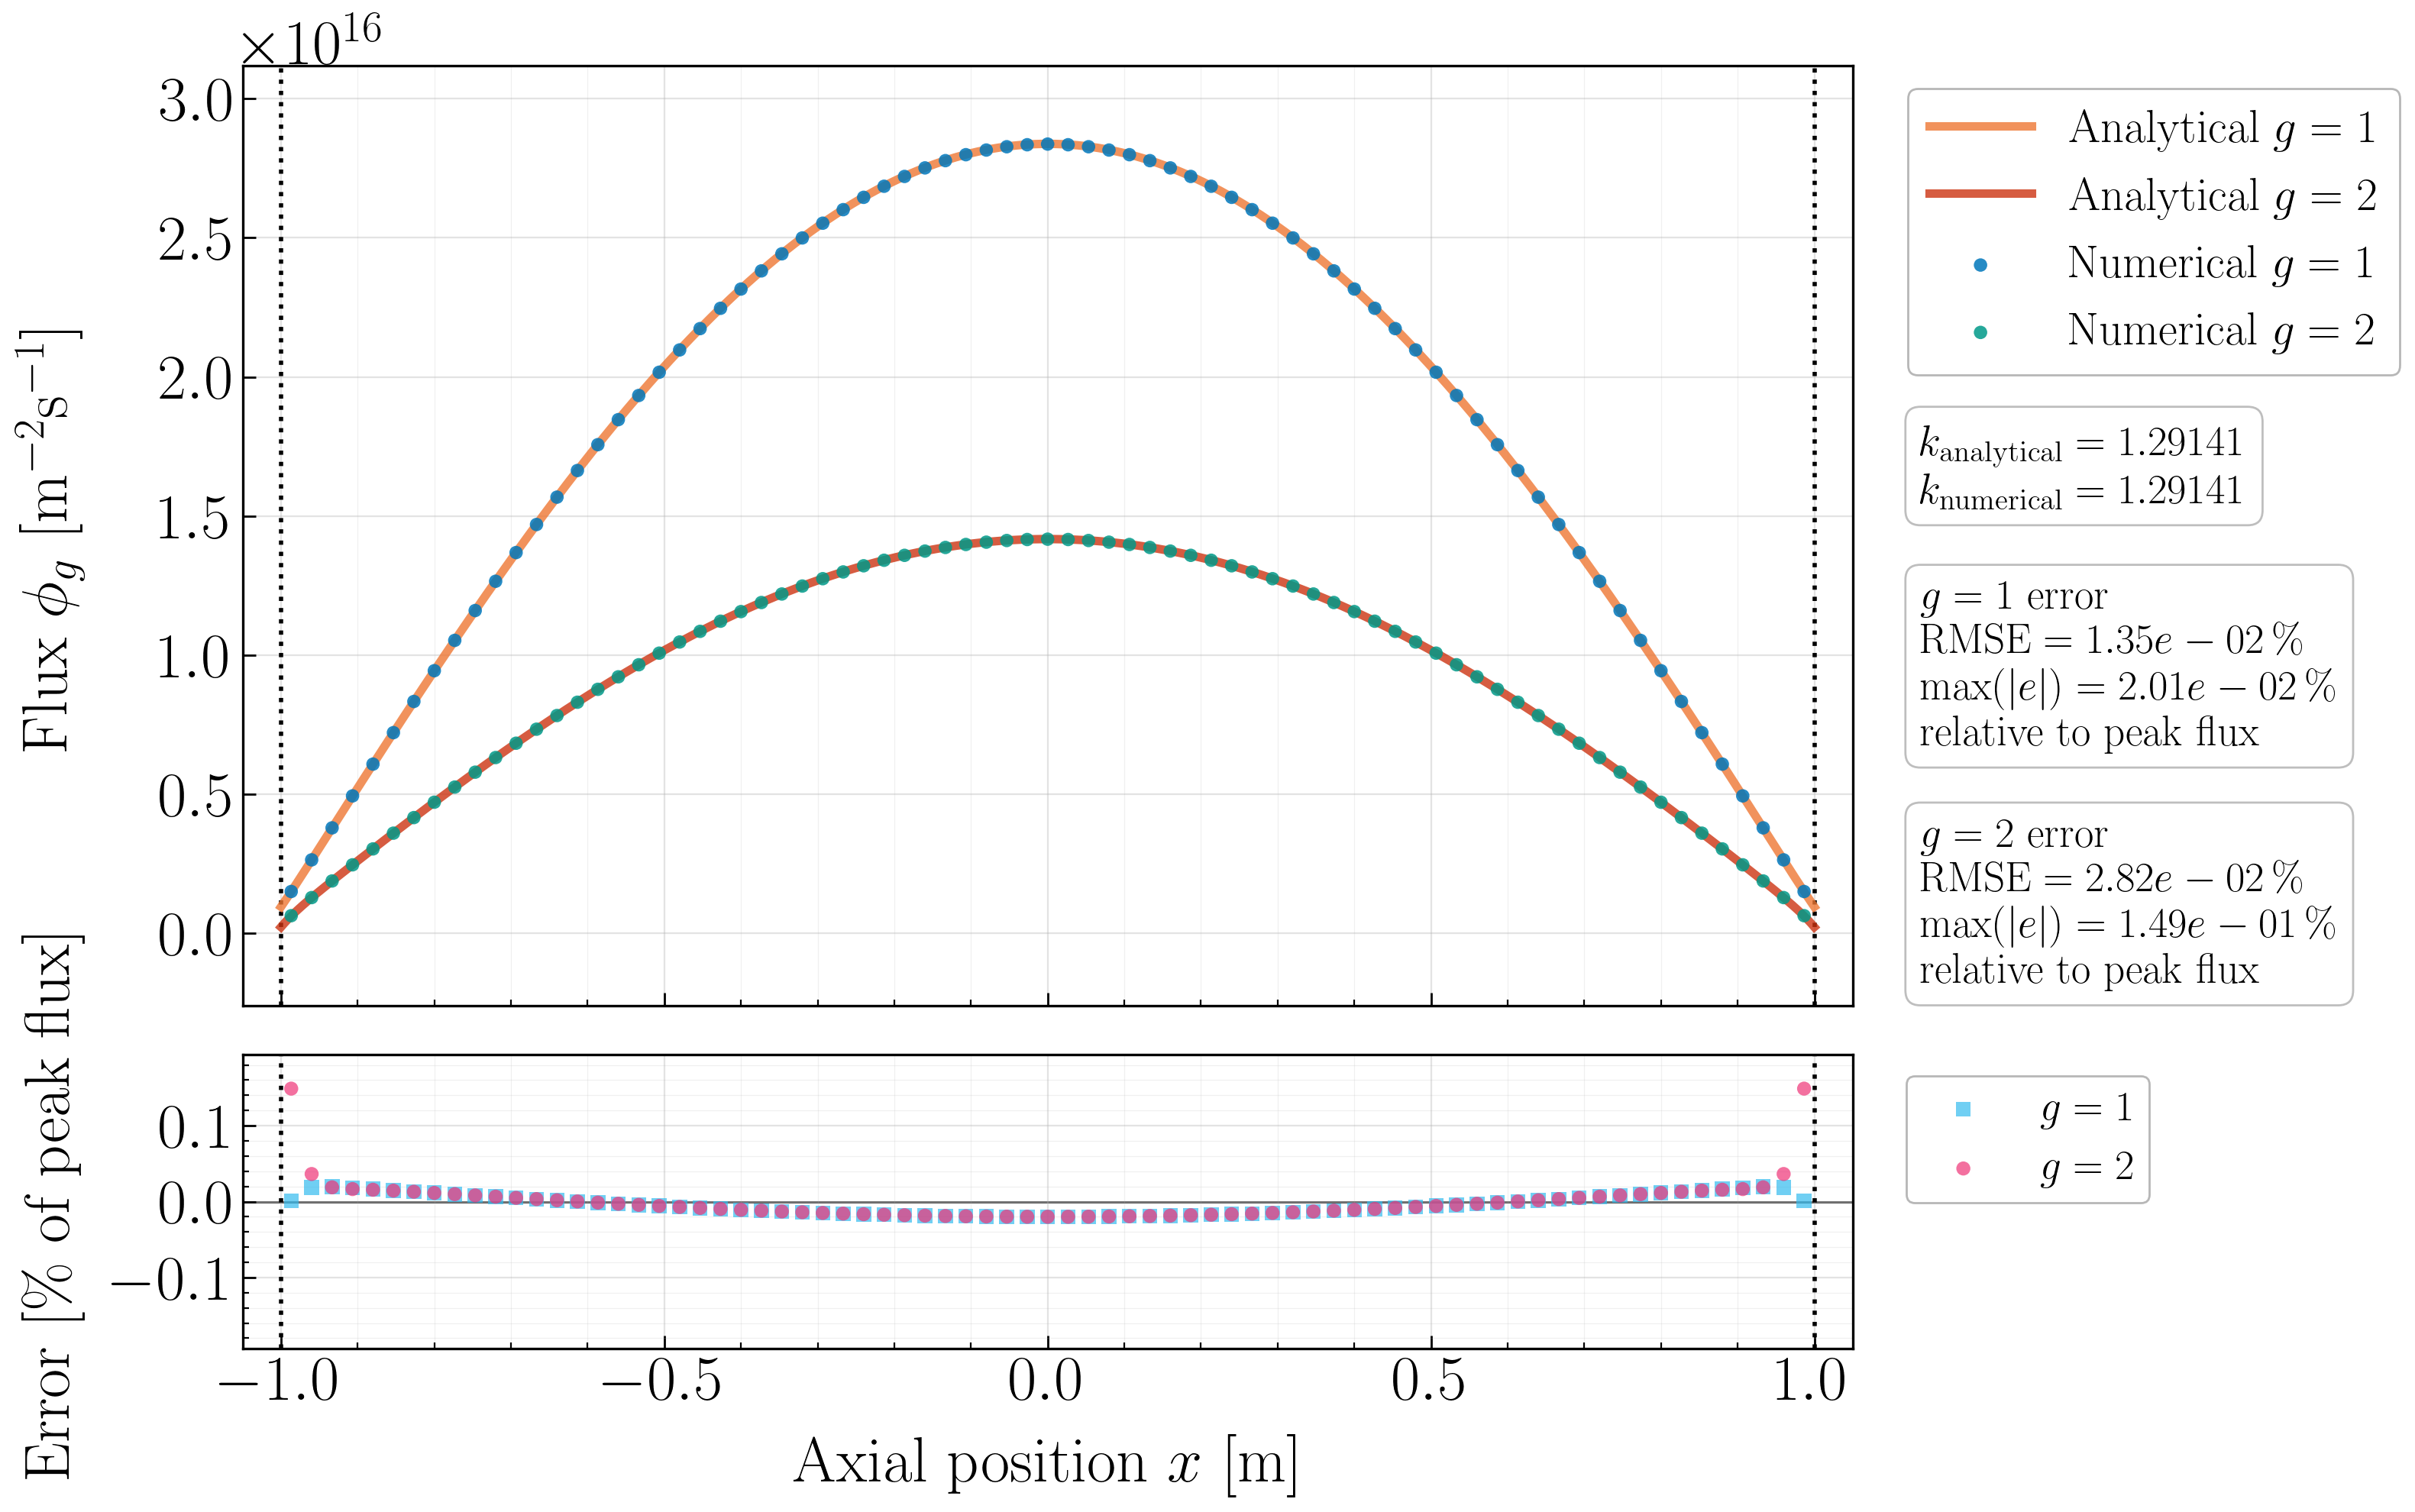

In [13]:
import matplotlib.pyplot as plt
import matplotlib as mpl

from utils.solver import Solver

mesh = d_class.NeutronicsMesh(
    N_R = 50,
    N_Z = 75,
    l = 2.0 # m
)
energy = d_class.NeutronicsEnergy(
    N_G = 2,
    power = 1000
)
cfg = d_class.NeutronicsConfig(mesh, energy)

neutronics_model = NeutronicsModel(cfg)
neutronics_model.interpolator_model = None

solver = Solver([neutronics_model])
solver.fsolve()


fig, axes, metrics = plot_two_group_neutronics_slab_validation(
    neutronics_model=neutronics_model,
    cfg=cfg,
    solution=solver.solution,
    k_bounds=(0.1, 5.0),
    yscale="linear",
    save_path="scripts/neutronics/neutronics_validation.pdf",
)

# phi_n_g, k = solver.solution      # type: ignore

# mpl.rcParams["text.usetex"] = True
# mpl.rcParams["font.family"] = "Computer modern"
# mpl.rcParams["font.size"] = 22

# fig = plt.figure(figsize=(16,9))
# ax = fig.add_subplot(111)

# colors = plt.cm.viridis(np.linspace(0, 1, 8))[::-1] # type: ignore
# ax.grid(alpha=0.4)
# for i in range(len(colors)):
#     ax.plot(phi_n_g[:, i], color=colors[i], label=i)
# ax.legend()
# ax.set_yscale("log")
# ax.set_title(r"$k_{eff} = $" + f"{k:.2f}")

# plt.show()